# **EDA**

## Exploratory analysis of each individual CSV file

In [38]:
#Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [39]:
#Read all csv files
df_2015 = pd.read_csv('C:/Users/Asus/OneDrive/Desktop/Workshop-003/data/2015.csv')
df_2016 = pd.read_csv('C:/Users/Asus/OneDrive/Desktop/Workshop-003/data/2016.csv')
df_2017 = pd.read_csv('C:/Users/Asus/OneDrive/Desktop/Workshop-003/data/2017.csv')
df_2018 = pd.read_csv('C:/Users/Asus/OneDrive/Desktop/Workshop-003/data/2018.csv')
df_2019 = pd.read_csv('C:/Users/Asus/OneDrive/Desktop/Workshop-003/data/2019.csv')

In [40]:
#Check the first record in each file
df_2015.head(1)
df_2016.head(1)
df_2017.head(1)
df_2018.head(1)
df_2019.head(1)

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.34,1.587,0.986,0.596,0.153,0.393


In [41]:
#View the column names in each dataset
print("Columnas 2015:", df_2015.columns.tolist())
print("Columnas 2016:", df_2016.columns.tolist())
print("Columnas 2017:", df_2017.columns.tolist())
print("Columnas 2018:", df_2018.columns.tolist())
print("Columnas 2019:", df_2019.columns.tolist())

Columnas 2015: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
Columnas 2016: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
Columnas 2017: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
Columnas 2018: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
Columnas 2019: ['Overall rank', 'Country or re

In [42]:
#Nulls per year in each 
print("Nulos 2015:", df_2015.isnull().sum())
print("Nulos 2016:", df_2016.isnull().sum())

Nulos 2015: Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64
Nulos 2016: Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64


In [43]:
print("Nulos 2017:", df_2017.isnull().sum())
print("Nulos 2018:", df_2018.isnull().sum())
print("Nulos 2019:", df_2019.isnull().sum())

Nulos 2017: Country                          0
Happiness.Rank                   0
Happiness.Score                  0
Whisker.high                     0
Whisker.low                      0
Economy..GDP.per.Capita.         0
Family                           0
Health..Life.Expectancy.         0
Freedom                          0
Generosity                       0
Trust..Government.Corruption.    0
Dystopia.Residual                0
dtype: int64
Nulos 2018: Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       1
dtype: int64
Nulos 2019: Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom 

In [44]:
#Remove the only null value from all data frames 
df_2018 = df_2018.dropna()

In [45]:
print("Nulos 2018:", df_2018.isnull().sum())

Nulos 2018: Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


In [46]:
#Rename all columns to a common format before merging the data frames
def normalized(df, year):
    df = df.copy() #Make a copy of the original DataFrame
    df['Year'] = year #Add a 'Year' column to identify the year of the data
 
    #Dictionary mapping
    rename_map = {
        'Happiness Score':               'Happiness_Score',
        'Happiness Rank':                'Happiness_Rank',
        'Economy (GDP per Capita)':      'GDP',
        'Family':                        'Social_Support',
        'Health (Life Expectancy)':      'Life_Expectancy',
        'Freedom':                       'Freedom',
        'Trust (Government Corruption)': 'Corruption',
        'Generosity':                    'Generosity',
        'Happiness.Score':               'Happiness_Score',
        'Happiness.Rank':                'Happiness_Rank',
        'Economy..GDP.per.Capita.':      'GDP',
        'Health..Life.Expectancy.':      'Life_Expectancy',
        'Trust..Government.Corruption.': 'Corruption',
        'Country or region':             'Country',
        'Score':                         'Happiness_Score',
        'Overall rank':                  'Happiness_Rank',
        'GDP per capita':                'GDP',
        'Social support':                'Social_Support',
        'Healthy life expectancy':       'Life_Expectancy',
        'Freedom to make life choices':  'Freedom',
        'Perceptions of corruption':     'Corruption',
    }
 
    df = df.rename(columns=rename_map)
 
    cols = ['Year', 'Country', 'Happiness_Rank', 'Happiness_Score',
            'GDP', 'Social_Support', 'Life_Expectancy',
            'Freedom', 'Corruption', 'Generosity']
 
    return df[[c for c in cols if c in df.columns]]

In [47]:
#Apply the normalization function to each yearly DataFrame
df_2015 = normalized(df_2015, 2015)
df_2016 = normalized(df_2016, 2016)
df_2017 = normalized(df_2017, 2017)
df_2018 = normalized(df_2018, 2018)
df_2019 = normalized(df_2019, 2019)

### Mergin Datasets

In [48]:
#Merge all yearly DataFrames into a single DataFrame
df = pd.concat([df_2015, df_2016, df_2017, df_2018, df_2019], ignore_index=True)
 
#Display the first 3 rows of the combined DataFrame
df.head(3)

,Year,Country,Happiness_Rank,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Corruption,Generosity
0,2015,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678
1,2015,Iceland,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630
2,2015,Denmark,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139


In [49]:
#Check for null values in the combined DataFrame
df.shape

(781, 10)

In [50]:
#Check for null values in the combined DataFrame
df.isnull().sum()

Year               0
Country            0
Happiness_Rank     0
Happiness_Score    0
GDP                0
Social_Support     0
Life_Expectancy    0
Freedom            0
Corruption         0
Generosity         0
dtype: int64

In [51]:
#Statistical summary of the unified dataset
df.describe()

,Year,Happiness_Rank,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Corruption,Generosity
count,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000,781.000000
mean,2016.992318,78.773367,5.377232,0.914537,1.078780,0.612342,0.411254,0.125436,0.218618
std,1.417814,45.162398,1.127071,0.405403,0.329581,0.248459,0.152911,0.105816,0.122394
min,2015.000000,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016.000000,40.000000,4.509000,0.605000,0.870210,0.440060,0.310480,0.054000,0.130000
50%,2017.000000,79.000000,5.321000,0.982000,1.125000,0.647239,0.431000,0.091000,0.202000
75%,2018.000000,118.000000,6.182000,1.233748,1.328000,0.808000,0.531000,0.156030,0.279060
max,2019.000000,158.000000,7.769000,1.870766,1.644000,1.141000,0.724000,0.551910,0.838075


In [52]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 781 entries, 0 to 780
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             781 non-null    int64  
 1   Country          781 non-null    str    
 2   Happiness_Rank   781 non-null    int64  
 3   Happiness_Score  781 non-null    float64
 4   GDP              781 non-null    float64
 5   Social_Support   781 non-null    float64
 6   Life_Expectancy  781 non-null    float64
 7   Freedom          781 non-null    float64
 8   Corruption       781 non-null    float64
 9   Generosity       781 non-null    float64
dtypes: float64(7), int64(2), str(1)
memory usage: 61.1 KB


Year               0
Country            0
Happiness_Rank     0
Happiness_Score    0
GDP                0
Social_Support     0
Life_Expectancy    0
Freedom            0
Corruption         0
Generosity         0
dtype: int64

### Check for outliers 

In [53]:
df.head(1)

,Year,Country,Happiness_Rank,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Corruption,Generosity
0,2015,Switzerland,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678


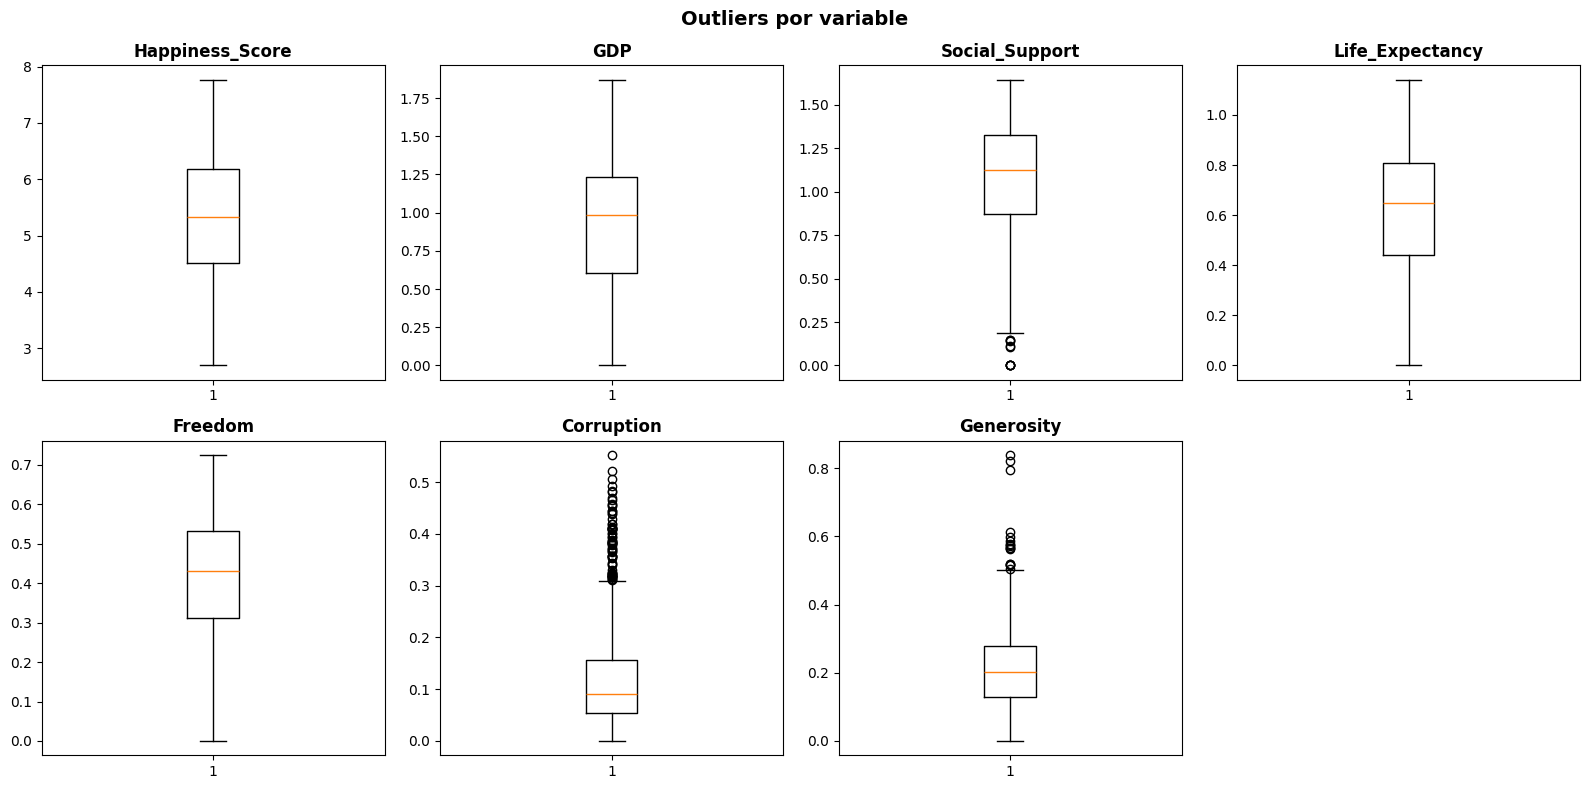

In [54]:
#Boxplot for detecting outliers
cols = [c for c in df.columns if c not in ['Year', 'Country', 'Happiness_Rank']]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontweight='bold')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outliers por variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 
Los outliers identificados en Corruption y Generosity corresponden a países 
con valores atípicos reales (ej. países con muy alta o muy baja percepción 
de corrupción). Se decide mantenerlos ya que representan casos reales 
y no errores de medición.

### Visualization

C:\Users\Asus\AppData\Local\Temp\ipykernel_25236\2749370376.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Year', y='Happiness_Score', ax=axes[0, 1], palette='Blues')


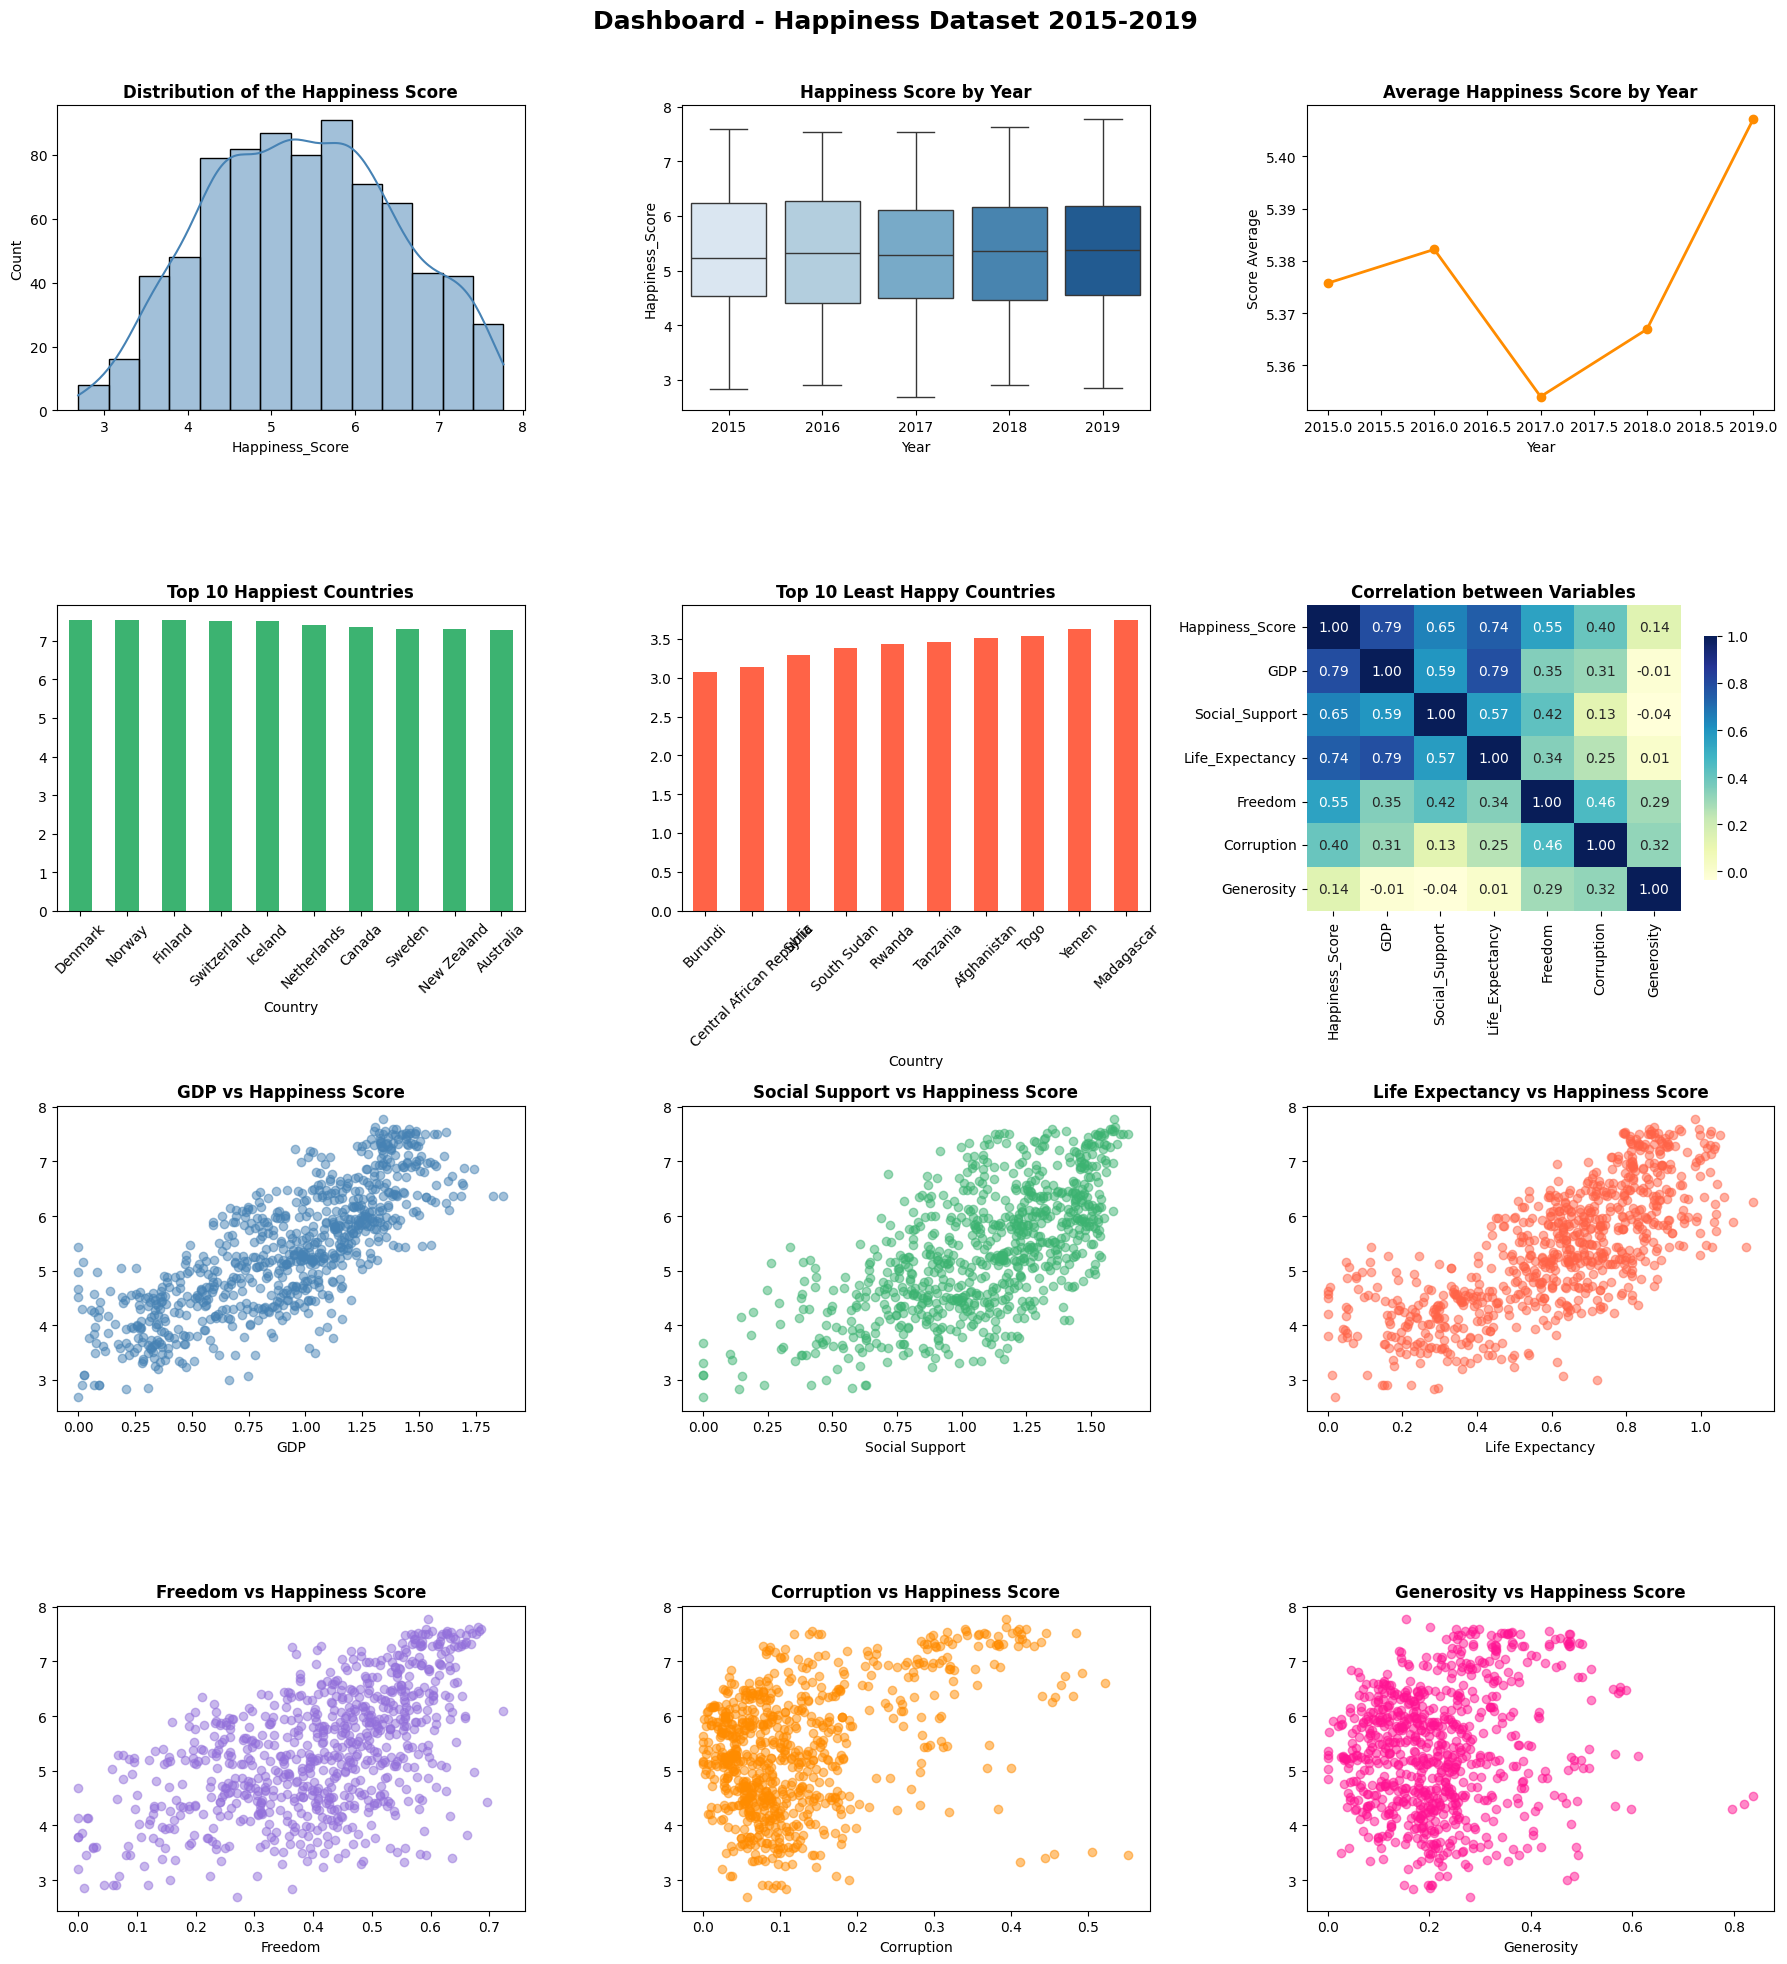

In [56]:
#Full Dashboard
fig, axes = plt.subplots(4, 3, figsize=(18, 20))

#1.Distribution of the Happiness Score
sns.histplot(df['Happiness_Score'], kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of the Happiness Score', fontweight='bold')

#2.Happiness Score by Year
sns.boxplot(data=df, x='Year', y='Happiness_Score', ax=axes[0, 1], palette='Blues')
axes[0, 1].set_title('Happiness Score by Year', fontweight='bold')

#3. Hapinnes Score annual average
df.groupby('Year')['Happiness_Score'].mean().plot(
    kind='line', ax=axes[0, 2], color='darkorange', marker='o', linewidth=2)
axes[0, 2].set_title('Average Happiness Score by Year', fontweight='bold')
axes[0, 2].set_ylabel('Score Average')

#4.Top 10 Happiest Countries
top10 = df.groupby('Country')['Happiness_Score'].mean().nlargest(10)
top10.plot(kind='bar', ax=axes[1, 0], color='mediumseagreen')
axes[1, 0].set_title('Top 10 Happiest Countries', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

#5.Top 10 Least Happy Countries
bottom10 = df.groupby('Country')['Happiness_Score'].mean().nsmallest(10)
bottom10.plot(kind='bar', ax=axes[1, 1], color='tomato')
axes[1, 1].set_title('Top 10 Least Happy Countries', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

#6.Correlation Heatmap
features = ['Happiness_Score', 'GDP', 'Social_Support', 'Life_Expectancy',
            'Freedom', 'Corruption', 'Generosity']
features = [f for f in features if f in df.columns]
corr = df[features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='YlGnBu',
            ax=axes[1, 2], cbar_kws={'shrink': 0.8})
axes[1, 2].set_title('Correlation between Variables', fontweight='bold')

#7.GDP vs Happiness Score
axes[2, 0].scatter(df['GDP'], df['Happiness_Score'], alpha=0.5, color='steelblue')
axes[2, 0].set_title('GDP vs Happiness Score', fontweight='bold')
axes[2, 0].set_xlabel('GDP')

#8.Social Support vs Happiness Score
axes[2, 1].scatter(df['Social_Support'], df['Happiness_Score'], alpha=0.5, color='mediumseagreen')
axes[2, 1].set_title('Social Support vs Happiness Score', fontweight='bold')
axes[2, 1].set_xlabel('Social Support')

#9.Life Expectancy vs Happiness Score
axes[2, 2].scatter(df['Life_Expectancy'], df['Happiness_Score'], alpha=0.5, color='tomato')
axes[2, 2].set_title('Life Expectancy vs Happiness Score', fontweight='bold')
axes[2, 2].set_xlabel('Life Expectancy')

#10.Freedom vs Happiness Score
axes[3, 0].scatter(df['Freedom'], df['Happiness_Score'], alpha=0.5, color='mediumpurple')
axes[3, 0].set_title('Freedom vs Happiness Score', fontweight='bold')
axes[3, 0].set_xlabel('Freedom')

#11.Corruption vs Happiness Score
axes[3, 1].scatter(df['Corruption'], df['Happiness_Score'], alpha=0.5, color='darkorange')
axes[3, 1].set_title('Corruption vs Happiness Score', fontweight='bold')
axes[3, 1].set_xlabel('Corruption')

#12.Generosity vs Happiness Score
axes[3, 2].scatter(df['Generosity'], df['Happiness_Score'], alpha=0.5, color='deeppink')
axes[3, 2].set_title('Generosity vs Happiness Score', fontweight='bold')
axes[3, 2].set_xlabel('Generosity')

plt.suptitle('Dashboard - Happiness Dataset 2015-2019', fontsize=18, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('C:/Users/Asus/OneDrive/Desktop/Workshop-003/notebooks/dashboard_eda.png', dpi=300)
plt.show()